<a href="https://colab.research.google.com/github/donlasSR/WasteClassification-By-Ann/blob/main/ann.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.impute import SimpleImputer,MissingIndicator
from sklearn.preprocessing import Normalizer,LabelEncoder, OneHotEncoder,StandardScaler,RobustScaler,MinMaxScaler
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
import os
import cv2
import numpy as np
from sklearn.decomposition import PCA
from tensorflow.keras.utils import to_categorical
from keras.callbacks import ReduceLROnPlateau
from keras.regularizers import l2
from keras.callbacks import EarlyStopping



In [ ]:
dp = '/content/drive/MyDrive/data'

# แสดงรายการไฟล์ในโฟลเดอร์
files = os.listdir(dp)
print(f"ไฟล์ในโฟลเดอร์: {files}")


ไฟล์ในโฟลเดอร์: ['process_dataset.zip', 'glass', 'metal', 'paper', 'plastic', 'waste']


In [ ]:

# เส้นทางของข้อมูล
data_path = '/content/drive/MyDrive/data'
categories = ['glass', 'metal', 'paper', 'plastic', 'waste']

# ขนาดภาพที่ต้องการ
img_size =  224

# ฟังก์ชันโหลดและประมวลผลข้อมูล
def load_data(data_path, categories, img_size):
    data = []
    for category in categories:
        path = os.path.join(data_path, category)  # เส้นทางไปยังโฟลเดอร์ของหมวดหมู่
        class_num = categories.index(category)  # กำหนดค่าหมวดหมู่เป็นตัวเลข
        for img in os.listdir(path):
            try:
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)  # โหลดภาพแบบสี
                resized_array = cv2.resize(img_array, (img_size, img_size))  # ปรับขนาดภาพ
                data.append([resized_array, class_num])
            except Exception as e:
                print(f"เกิดข้อผิดพลาดกับไฟล์: {img}, ข้อผิดพลาด: {e}")
    return data

# โหลดข้อมูล
data = load_data(data_path, categories, img_size)

# สุ่มข้อมูลเพื่อไม่ให้มี bias
import random
random.shuffle(data)

# แยก X และ y
X = []  # ฟีเจอร์
y = []  # เลเบล

for features, label in data:
    X.append(features)
    y.append(label)

# แปลงเป็น numpy array
X = np.array(X).reshape(-1, img_size, img_size, 3)  # 3 สำหรับภาพสี (RGB)
y = np.array(y)

print("ข้อมูลพร้อมใช้งาน!")


ข้อมูลพร้อมใช้งาน!


In [ ]:
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (2250, 224, 224, 3)
Shape of y: (2250,)


In [ ]:

# One-hot encoding
y_train = to_categorical(y_train, num_classes=5)
y_test = to_categorical(y_test, num_classes=5)


# แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Flatten ข้อมูล
X_train_flatten = X_train.reshape(X_train.shape[0], -1)  # (จำนวนตัวอย่าง, 49152)
X_test_flatten = X_test.reshape(X_test.shape[0], -1)

# ลดมิติข้อมูลด้วย PCA
pca = PCA(n_components=21)
X_train_pca = pca.fit_transform(X_train_flatten)
X_test_pca = pca.transform(X_test_flatten)

# สร้างโมเดล ANN สำหรับ 5 class
model = Sequential()
model.add(Dense(128, activation='tanh'))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(32, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dense(16, activation='relu'))
model.add(Dense(5, activation='softmax'))  # 5 classes

# Compile โมเดล
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

# early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)



In [ ]:
# Train โมเดล
history = model.fit(X_train_pca, y_train, epochs=200, validation_data=(X_test_pca, y_test),
                    batch_size=32, callbacks=[lr_scheduler])
# Evaluate โมเดล
test_loss, test_accuracy = model.evaluate(X_test_pca, y_test)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Epoch 1/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.2257 - loss: 2.1257 - val_accuracy: 0.3533 - val_loss: 1.8762 - learning_rate: 0.0010
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3275 - loss: 1.8773 - val_accuracy: 0.4378 - val_loss: 1.6978 - learning_rate: 0.0010
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4093 - loss: 1.6877 - val_accuracy: 0.4511 - val_loss: 1.5867 - learning_rate: 0.0010
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4168 - loss: 1.6121 - val_accuracy: 0.4711 - val_loss: 1.5139 - learning_rate: 0.0010
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4553 - loss: 1.5330 - val_accuracy: 0.4822 - val_loss: 1.4618 - learning_rate: 0.0010
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4530 - loss: 1.4904 - val_accuracy: 0.4822 - val_loss: 1.3979 - learning_rate: 0.0010
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4911 - loss: 1.4096 - val_acc

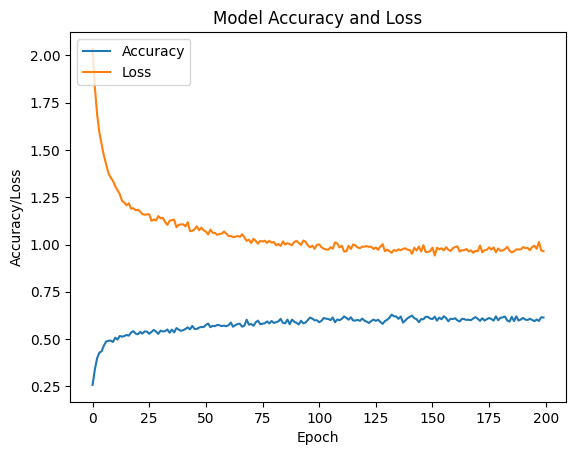

In [ ]:
accuracy = history.history['accuracy']
loss = history.history['loss']
plt.plot(history.history['accuracy'])
plt.plot(history.history['loss'])
plt.title('Model Accuracy and Loss')
plt.ylabel('Accuracy/Loss')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Loss'], loc='upper left')
plt.show()

In [ ]:
model.evaluate(X_test_pca,y_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5798 - loss: 1.0864 


[1.085546612739563, 0.5866666436195374]

In [ ]:
# ทำนายค่าความน่าจะเป็นด้วยโมเดล
y_pred = model.predict(X_test_pca)  # (จำนวนตัวอย่าง, จำนวนคลาส)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [ ]:
# แปลงค่าความน่าจะเป็นเป็น class labels
y_pred_classes = np.argmax(y_pred, axis=1)  # ผลลัพธ์เป็น (จำนวนตัวอย่าง,)

In [ ]:
 cm = confusion_matrix(y_test, y_pred_classes)

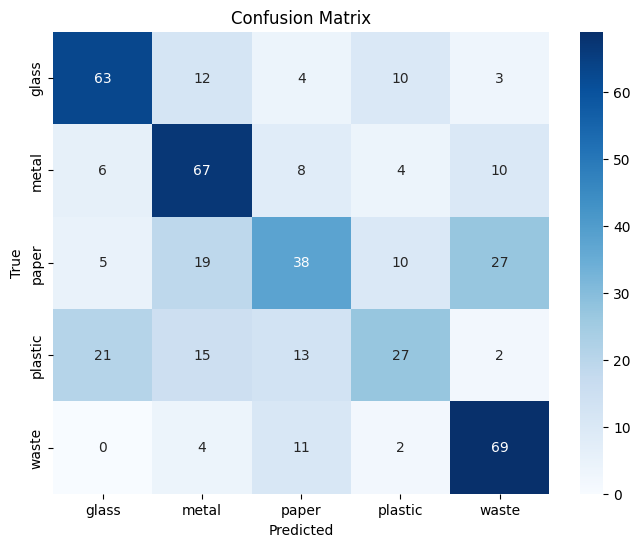

In [ ]:

# Plot Confusion Matrix using Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=categories, yticklabels=categories)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
